<a href="https://colab.research.google.com/github/b00001/sciusproject-hyperthermia/blob/main/Nanoparticle_Temperature_vs_Time_LRT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rosensweig 2002, JMMM 252:370 https://ui.adsabs.harvard.edu/abs/2002JMMM..252..370R/abstract

| Magnetic solid | Chemical formula | Ms (kA m−1) | K (kJ m−3) | c (J kg−1 K−1) | ρ (kg m−3) |
|---|---|---|---|---|---|
| Maghemite | γ-Fe2O3 | 414 | −4.6 | ∼746 | 4600 |
| Magnetite | FeO·Fe2O3 | 446 | 23–41 | 670 | 5180 |
| Cobalt ferrite | CoO·Fe2O3 | 425 | 180–200 | 700 | 4907 |
| Barium ferrite | BaO·6Fe2O3 | 380 | 300–330 | ∼650 | 5280 |


In [182]:
#USE ONLY THE UNITS SPECIFIED IN THE COMMENTS AFTER EACH VALUE IN THIS CELL

Ms_in = 446e3            # [A/m]
K_in = 32e3               # [J/m^3]
Cp_in = 670                # [J/(kg K)]
rho_in = 5180              # [kg/m^3]

In [183]:
import numpy as np
import matplotlib.pyplot as plt

# ===========INPUT===========

In [184]:
def get_val(var):
    if isinstance(var, list) and len(var) == 3:
        return np.arange(var[0], var[2] + (var[1]/2), var[1])
    return np.array(var, dtype=float)

kB_in = 1.380649e-23        # [J/K]
mu0_in = 4 * np.pi * 1e-7   # [H/m]
tau0_in = 1e-9              # [s]

H_app_in = 0.1e-3             # [Tesla]
eta_in = 0.0015             # [Pa s]
T_in = [300, 10, 500]                  # [K]
f_in = 300e3              # [Hz]
delta_in = 0.1e-9           # [m]
R_in = 10e-9           # [m]

kB = get_val(kB_in)
mu0 = get_val(mu0_in)
tau0 = get_val(tau0_in)
rho = get_val(rho_in)
Cp = get_val(Cp_in)
Ms = get_val(Ms_in)
K = get_val(K_in)
eta = get_val(eta_in)
T = get_val(T_in)
f = get_val(f_in)
delta = get_val(delta_in)
R = get_val(R_in)

H_app = get_val(H_app_in) / mu0                  # tesla เป็น [A/m]
omega = 2 * np.pi * f                        # [rad/s]

==================================================================
 Nanoparticle Temperature vs Time (Magnetic Hyperthermia, LRT)
==================================================================

Validity check: LRT applies when xi = (mu0 * Ms * V_H * H0) / (kB * T) <= 1
Safety imit H0F <= 1.51 * 10^8 A m-1 s-1

HOW IT WORKS
------------
Fixed inputs: viscosity (eta), frequency (f), core radius (R),
              shell thickness (delta)

Field: H(t) amplitude is defined as a function of time

Procedure:
  1. Set initial temperature T_initial
  2. Loop over each time step (n_steps = t_total / dt):
       - compute H(t)
       - compute relaxation times (tau_B, tau_N, tau_eff)
       - compute chi0 and chi'' (out-of-phase susceptibility)
       - compute power dissipation P
       - compute heating rate and update temperature
       - store H(t), heating rate, temperature, and xi
  3. Stop if xi >= 1 (outside the linear response regime)


In [185]:
dt        = 1e-3      # [s]  time step
t_total   = 200       # [s]  เวลารวม
n_steps   = int(t_total / dt)
T_initial = 309.0     # [K]

# ================================================================
# ================================================================
eta   = 0.0015        # [Pa s]
f     = 100e3         # [Hz]
delta = 1e-9          # [m]
R     = 6e-9          # [m]

omega = 2 * np.pi * f
VM = (4.0 / 3.0) * np.pi * R ** 3
VH = (4.0 / 3.0) * np.pi * (R + delta) ** 3

# ================================================================
#  H_A(t) : amplitude ของสนาม [Tesla] เป็นฟังก์ชันของเวลา
#  >>> แก้สูตรตรงนี้ทีเดียว <<<
# ================================================================
H_max = 1.88e-3      # [T] ค่าช่วงแรก (ที่ราบสูง)
H_min = 0e-3    # [T] ค่าหลังดิ่งลง (ที่ราบต่ำ)
t0    = 12.0      # [s] จุดกึ่งกลางที่ดิ่งลง
w     = 0.8       # [s] ความชัน (เล็ก = ดิ่งชันขึ้น)

H_of_t = lambda t: H_min + (H_max - H_min) / (1 + np.exp((t - t0) / w))


In [186]:
time_array = np.zeros(n_steps + 1)
Temp_array = np.zeros(n_steps + 1)
P_array    = np.zeros(n_steps + 1)
xi_array   = np.zeros(n_steps + 1)
H_array    = np.zeros(n_steps + 1)

Temp_array[0] = T_initial
H_array[0]    = H_of_t(0.0)
xi_array[0]   = (mu0 * Ms * VH * (H_array[0] / mu0)) / (kB * T_initial)

tem_i  = T_initial
last_i = n_steps

# ================================================================
#  LOOP
# ================================================================
for i in range(1, n_steps + 1):

    t   = i * dt
    H_T = H_of_t(t)          # amplitude [Tesla] ณ เวลา t
    H_A = H_T / mu0          # Tesla -> A/m

    # ---- relaxation times ----
    gamma   = (K * VM) / (kB * tem_i)
    tau_b   = (3 * eta * VH) / (kB * tem_i)
    tau_n   = (tau0 / 2) * np.exp(gamma)
    tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))

    # ---- susceptibility & power ----
    chi0 = (mu0 * Ms ** 2 * VM) / (3 * kB * tem_i)
    chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)
    P = mu0 * H_A ** 2 * f * np.pi * chi_doubleprime

    # ---- update temperature ----
    tem_i = tem_i + (P / (rho * Cp)) * dt

    # ---- เก็บผลลัพธ์ ----
    time_array[i] = t
    Temp_array[i] = tem_i
    P_array[i]    = P
    H_array[i]    = H_T

    # ---- ตรวจเงื่อนไข LRT (xi << 1) ----
    xi = (mu0 * Ms * VM * H_A) / (kB * tem_i)
    xi_array[i] = xi
    if xi >= 1:
        print(f"ไม่ได้: xi = {xi:.3f} >= 1 ที่ t = {t:.2f} s")
        print(f"อุณหภูมิล่าสุด = {tem_i:.4f} K")
        last_i = i
        break




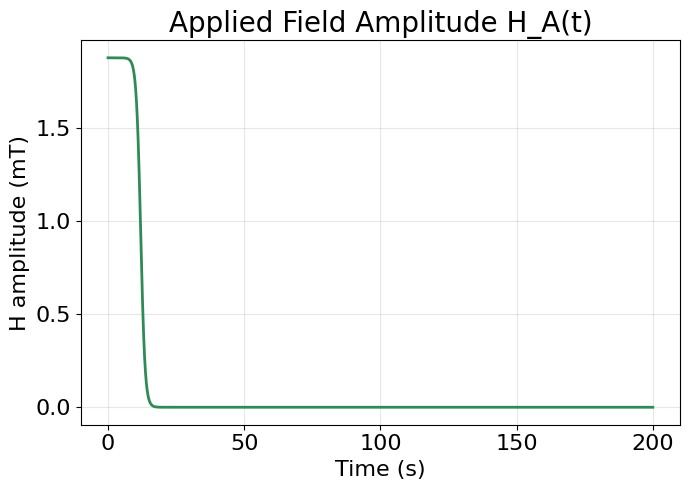

In [187]:
# ================================================================
#  PLOT
# ================================================================
sl = slice(None)
# ---- H(t) ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], H_array[sl] * 1e3, color='seagreen', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('H amplitude (mT)', fontsize=16)
plt.title('Applied Field Amplitude H_A(t)', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

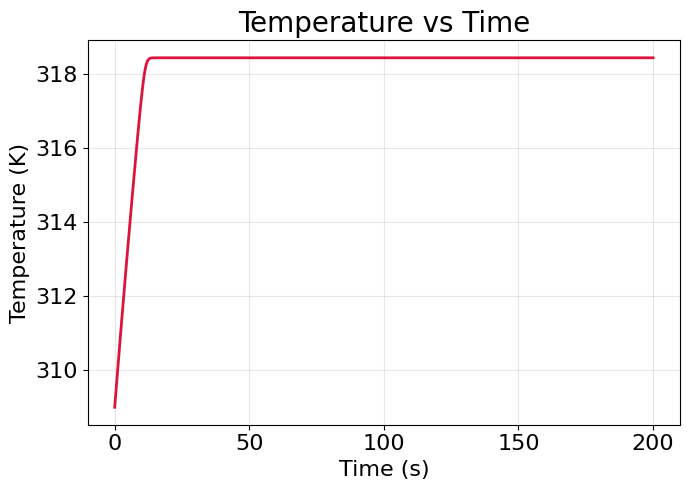

อุณหภูมิสุดท้ายที่ t = 200.00 s: 318.4505 K


In [188]:
# ---- Temperature vs Time ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], Temp_array[sl], color='crimson', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('Temperature (K)', fontsize=16)
plt.title('Temperature vs Time', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()
print(f"อุณหภูมิสุดท้ายที่ t = {time_array[last_i]:.2f} s: {Temp_array[last_i]:.4f} K")

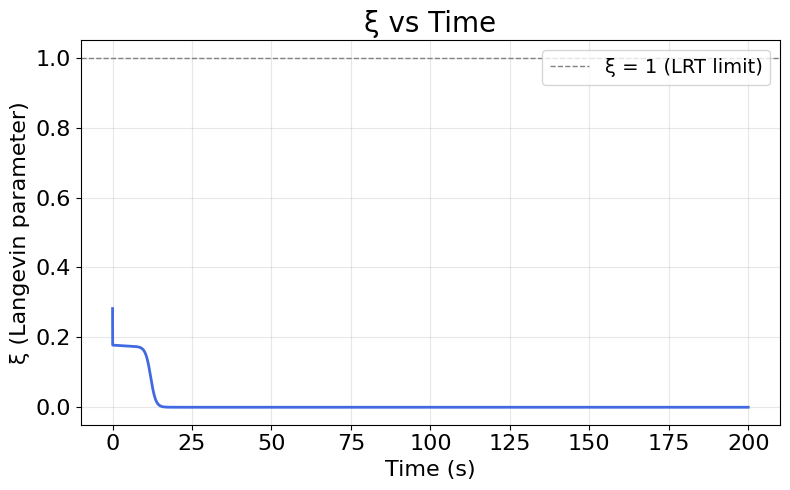

In [189]:
# ---- xi vs Time ----
plt.figure(figsize=(8, 5))
plt.plot(time_array[sl], xi_array[sl], color='royalblue', linewidth=2)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='ξ = 1 (LRT limit)')
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('ξ (Langevin parameter)', fontsize=16)
plt.title('ξ vs Time', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

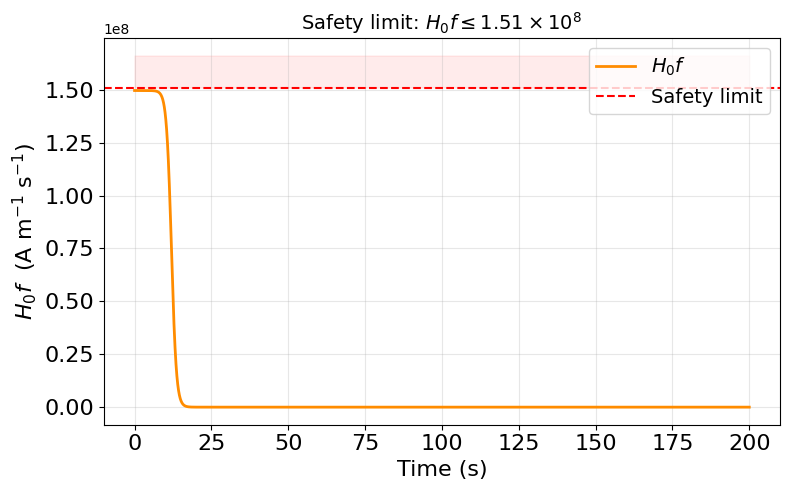

In [190]:
# ================================================================
#  ---- H0*f safety limit (Atkinson-Brezovich) vs Time ----
# ================================================================
Hf_limit = 1.51e8                 # [A/(m s)]  ขีดจำกัดความปลอดภัย

sl = slice(0, last_i + 1)         # ตัดช่วงที่ยังไม่ได้คำนวณทิ้ง (เผื่อ loop break)

H0_array = H_array / mu0          # [A/m]       amplitude ในหน่วย A/m
Hf_array = H0_array * f           # [A/(m s)]   ผลคูณ H0*f

plt.figure(figsize=(8, 5))
plt.plot(time_array[sl], Hf_array[sl], color='darkorange', linewidth=2, label='$H_0 f$')
plt.axhline(y=Hf_limit, color='red', linestyle='--', linewidth=1.5, label='Safety limit')
plt.fill_between(time_array[sl], Hf_limit, max(Hf_array[sl].max(), Hf_limit) * 1.10,
                 color='red', alpha=0.08)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('$H_0 f$  (A m$^{-1}$ s$^{-1}$)', fontsize=16)
plt.title('Safety limit: $H_0 f \\leq 1.51\\times10^{8}$', fontsize=14)
plt.legend(loc='upper right', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

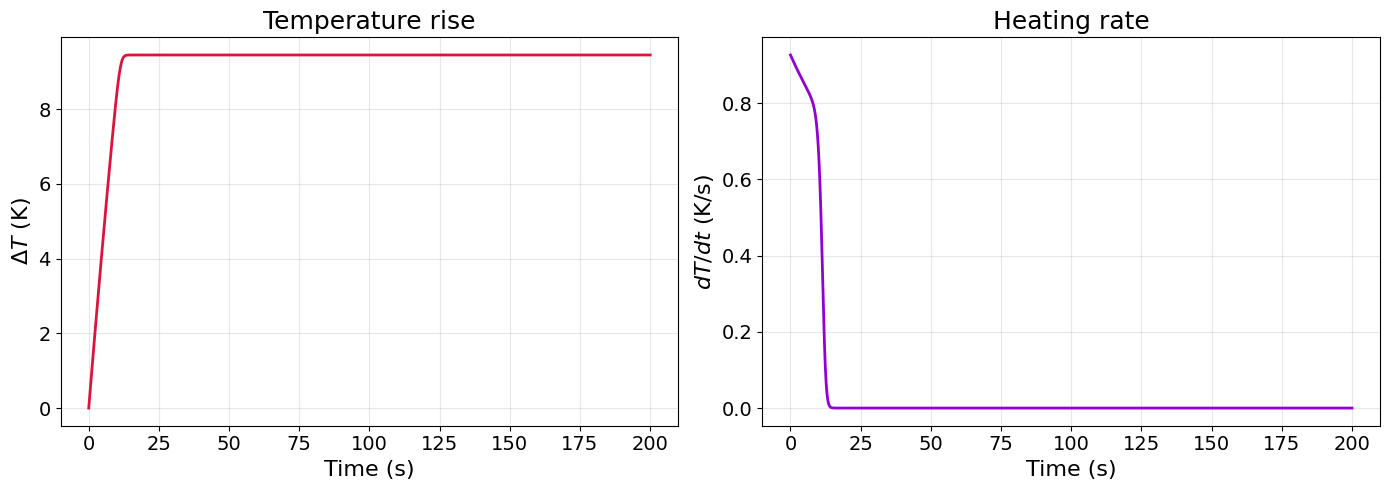

  t [s]      T [K]     dT [K]      P [W/m3]   dT/dt [K/s]   SAR [W/kg]  H0f/limit        xi
    0.0   309.0000     0.0000    0.0000e+00    0.0000e+00   0.0000e+00      0.991    0.2824
    0.1   309.0925     0.0925    3.2079e+06    9.2431e-01   6.1929e+02      0.991    0.1778
    0.2   309.1849     0.1849    3.2022e+06    9.2265e-01   6.1818e+02      0.991    0.1777
    0.3   309.2770     0.2770    3.1964e+06    9.2100e-01   6.1707e+02      0.991    0.1777
    0.4   309.3691     0.3691    3.1907e+06    9.1936e-01   6.1597e+02      0.991    0.1776
    0.5   309.4609     0.4609    3.1851e+06    9.1773e-01   6.1488e+02      0.991    0.1776
    0.6   309.5526     0.5526    3.1794e+06    9.1610e-01   6.1378e+02      0.991    0.1775
    0.7   309.6441     0.6441    3.1738e+06    9.1447e-01   6.1270e+02      0.991    0.1775
    0.8   309.7355     0.7355    3.1681e+06    9.1285e-01   6.1161e+02      0.991    0.1774
    0.9   309.8267     0.8267    3.1626e+06    9.1124e-01   6.1053e+02      0.99

In [191]:
# ================================================================
#  ---- Heating vs Time ----
# ================================================================
dT_array   = Temp_array - T_initial     # [K]      อุณหภูมิที่เพิ่มขึ้น
rate_array = P_array / (rho * Cp)       # [K/s]    อัตราการให้ความร้อน
SAR_array  = P_array / rho              # [W/kg]   specific absorption rate

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(time_array[sl], dT_array[sl], color='crimson', linewidth=2)
ax[0].set_xlabel('Time (s)', fontsize=16)
ax[0].set_ylabel('$\\Delta T$ (K)', fontsize=16)
ax[0].set_title('Temperature rise', fontsize=18)
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis='both', labelsize=14)

sl1 = slice(1, last_i + 1)
ax[1].plot(time_array[sl1], rate_array[sl1], color='darkviolet', linewidth=2)
ax[1].set_xlabel('Time (s)', fontsize=16)
ax[1].set_ylabel('$dT/dt$ (K/s)', fontsize=16)
ax[1].set_title('Heating rate', fontsize=18)
ax[1].grid(True, alpha=0.3)
ax[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

# ---- ตารางข้อมูลทุก 10 s ----
print(f"{'t [s]':>7} {'T [K]':>10} {'dT [K]':>10} {'P [W/m3]':>13}"
      f" {'dT/dt [K/s]':>13} {'SAR [W/kg]':>12} {'H0f/limit':>10} {'xi':>9}")
for t_mark in np.arange(0.0, time_array[last_i] + 1e-9, 1e-1 ):
    j = int(round(t_mark / dt))
    if j > last_i:
        break
    print(f"{time_array[j]:7.1f} {Temp_array[j]:10.4f} {dT_array[j]:10.4f}"
          f" {P_array[j]:13.4e} {rate_array[j]:13.4e} {SAR_array[j]:12.4e}"
          f" {Hf_array[j]/Hf_limit:10.3f} {xi_array[j]:9.4f}")

print(f"\nΔT รวม = {dT_array[last_i]:.4f} K")
print(f"อัตราสูงสุด = {rate_array[sl].max():.4e} K/s,  SAR สูงสุด = {SAR_array[sl].max():.4e} W/kg")